In [4]:
!pip install opencv-python pandas matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from google.colab import files

In [5]:
uploaded = files.upload()

Saving pecas.jpg to pecas.jpg


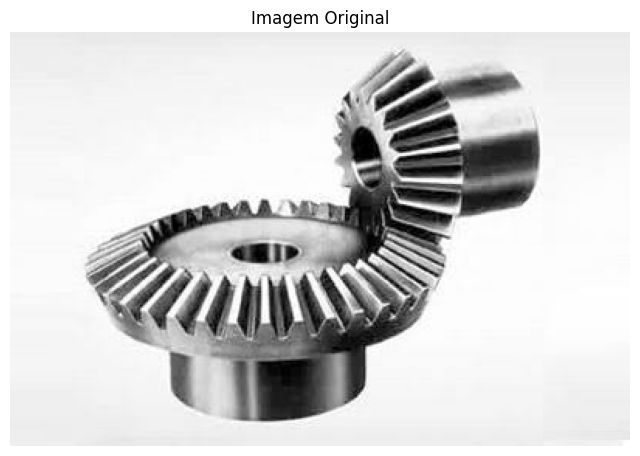

In [6]:
nome_imagem = "pecas.jpg"

imagem = cv2.imread(nome_imagem)


imagem_rgb = cv2.cvtColor(
    imagem,
    cv2.COLOR_BGR2RGB
)


plt.figure(figsize=(8,6))
plt.imshow(imagem_rgb)
plt.title("Imagem Original")
plt.axis("off")
plt.show()

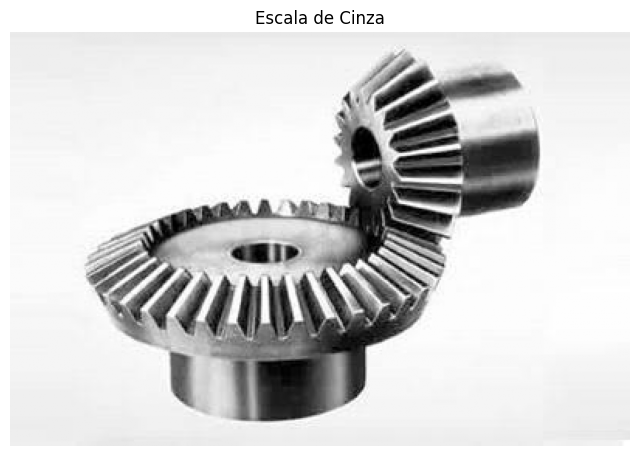

In [7]:
cinza = cv2.cvtColor(
    imagem,
    cv2.COLOR_BGR2GRAY
)


blur = cv2.GaussianBlur(
    cinza,
    (5,5),
    0
)


plt.figure(figsize=(8,6))
plt.imshow(cinza, cmap="gray")
plt.title("Escala de Cinza")
plt.axis("off")
plt.show()

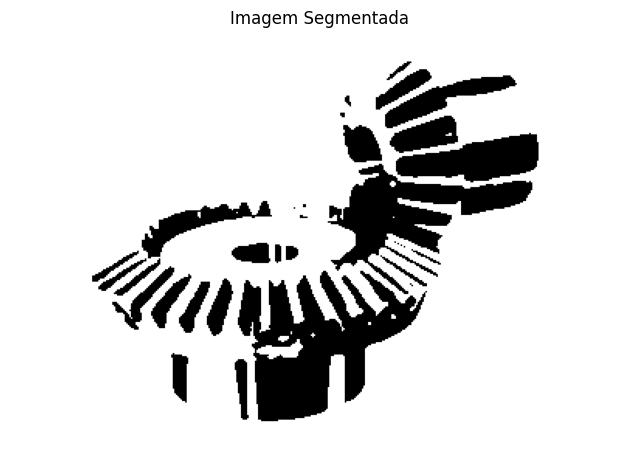

In [8]:
_, thresh = cv2.threshold(
    blur,
    120,
    255,
    cv2.THRESH_BINARY
)


plt.figure(figsize=(8,6))
plt.imshow(thresh,cmap="gray")
plt.title("Imagem Segmentada")
plt.axis("off")
plt.show()

In [9]:
contornos, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


print("Quantidade de objetos encontrados:", len(contornos))

Quantidade de objetos encontrados: 1


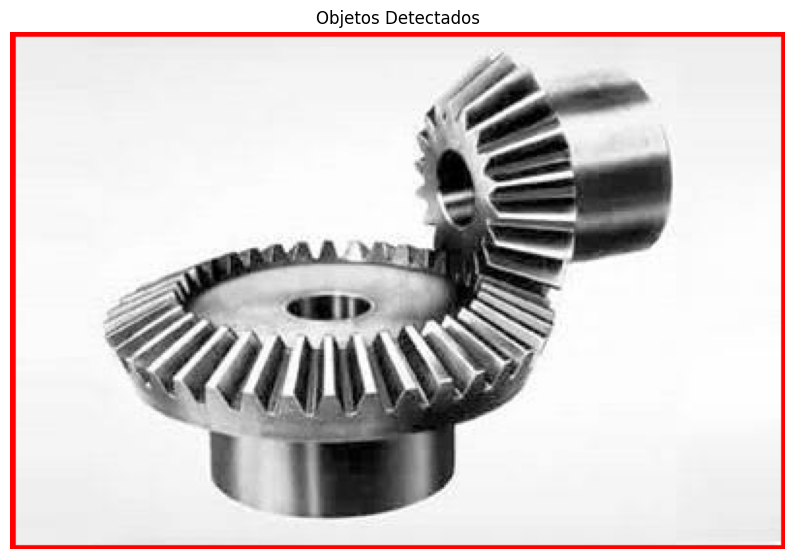

In [10]:
resultado = imagem_rgb.copy()

dados = []

contador = 1


for contorno in contornos:

    area = cv2.contourArea(contorno)


    if area > 500:

        x,y,w,h = cv2.boundingRect(contorno)


        cv2.rectangle(
            resultado,
            (x,y),
            (x+w,y+h),
            (255,0,0),
            3
        )


        cv2.putText(
            resultado,
            f"Objeto {contador}",
            (x,y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255,0,0),
            2
        )


        proporcao = w/h


        dados.append(
            [
                contador,
                area,
                w,
                h,
                proporcao
            ]
        )


        contador += 1



plt.figure(figsize=(10,7))
plt.imshow(resultado)
plt.title("Objetos Detectados")
plt.axis("off")
plt.show()

In [12]:
tabela = pd.DataFrame(
    dados,
    columns=[
        "Objeto",
        "Area",
        "Largura",
        "Altura",
        "Proporcao"
    ]
)


tabela

,Objeto,Area,Largura,Altura,Proporcao
0,1,106134.0,400,267,1.498127


In [13]:
def classificar(area):

    if area < 2000:
        return "Pequeno"

    elif area < 6000:
        return "Medio"

    else:
        return "Grande"



tabela["Classificacao"] = tabela["Area"].apply(classificar)


tabela

,Objeto,Area,Largura,Altura,Proporcao,Classificacao
0,1,106134.0,400,267,1.498127,Grande


In [14]:
cv2.imwrite(
    "resultado_final.jpg",
    cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR)
)


print("Imagem salva!")

Imagem salva!


In [15]:
files.download("resultado_final.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>